## **BIO Sex Classification**

Using device: cuda
STEP 1: Loading Data
✓ Loaded phenotype: (16340, 53)
✅ Loaded 414 ROI labels from dataset/roi_labels.csv
✓ Loaded fMRI: (16340, 490, 414)
  Subjects: 16340
  Timepoints: 490
  Brain regions: 414
  ROI labels: 414
✓ All required columns present

STEP 2: Preparing Data Loaders for Sex Prediction
🧼 Cohort size: 16340 subjects
   → Cases: 7613 (46.6%)
   → Controls: 8727

✅ Final prevalence: 0.466
   Splits → Train: 11438, Val: 2451, Test: 2451

📊 Dataset Meta
  target: Sex
  n_total: 16340
  n_positive: 7613
  prevalence: 0.465911865234375
  feature_dim: 414
  n_train: 11438
  n_val: 2451
  n_test: 2451

STEP 3: Initializing BBTransformer with Best Tuned Config
✓ Model created with 25,747,042 parameters
  → Ready for Ranger21 + BCEWithLogitsLoss

STEP 4: Training with train_model (Ranger21 Optimizer)


Early stopping triggered at epoch 173

✅ Training complete with Ranger21!

STEP 5: Test Set Evaluation



🧪 Performance Metrics:
  Accuracy:  0.9364
  Precision: 0.9332
  Recall:    0.9299
  F1 Score:  0.9316
  ROC-AUC:   0.9815

📊 Confusion Matrix:
[[1233   76]
 [  80 1062]]


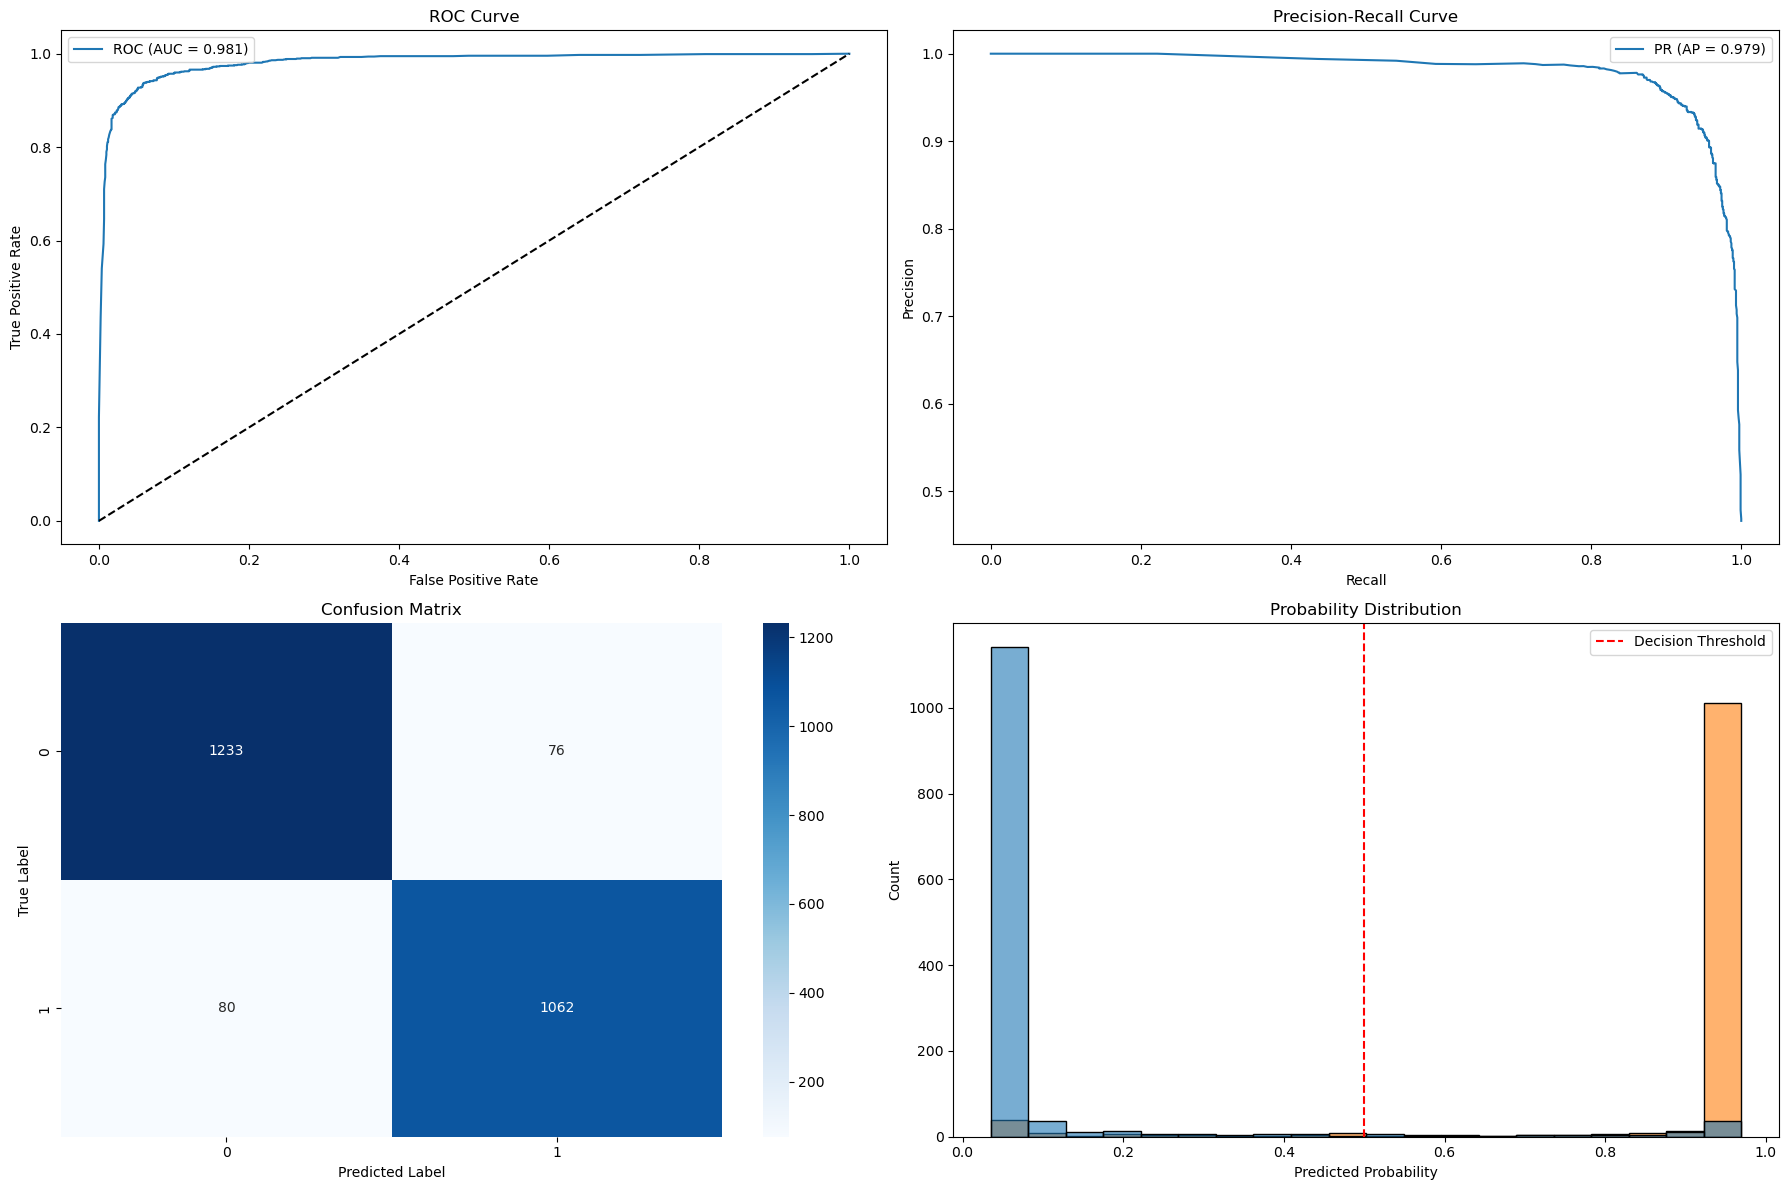

✅ Saved evaluation plots to sex_prediction_results_new.png

STEP 6: Permutation Importance (CSV)


Calculating permutation importance for 414 brain regions...


Permuting regions: 100%|██████████| 414/414 [29:43<00:00,  4.31s/it]


✅ Saved top 30 features to: dataset/importance_Sex.csv


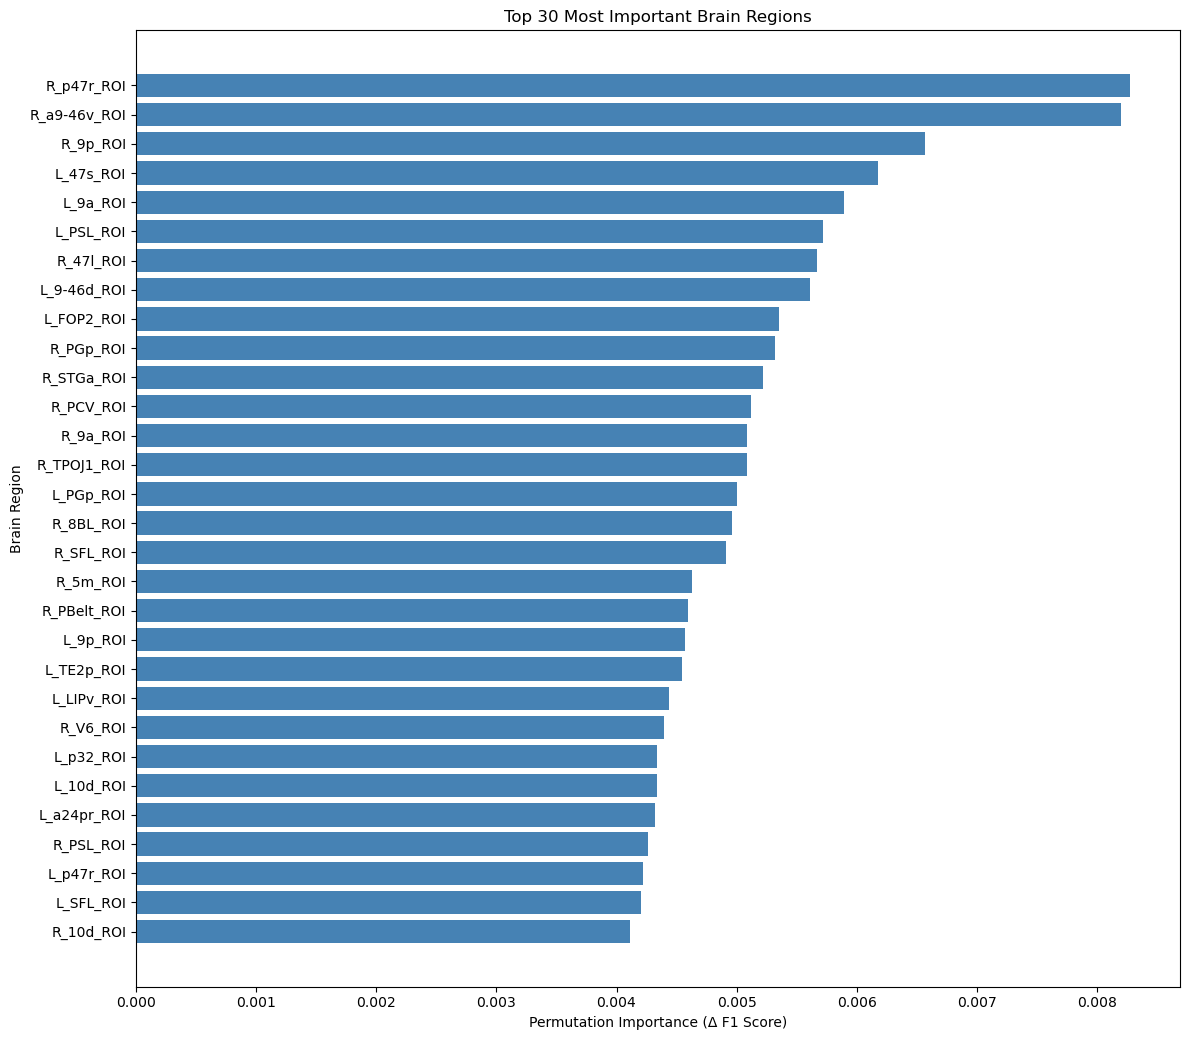

✅ Saved plot to dataset/importance_Sex_plot.png
✅ Permutation importance saved.

STEP 7: Single Subject Prediction
Prediction for subject 1000097:
  Prediction: 0
  Probability: 0.0391

✅ ALL STEPS COMPLETED SUCCESSFULLY
→ Architecture: Enhanced BBTransformer (Optuna-tuned)
→ Optimizer: Ranger21 (8 SOTA components)
→ Performance: F1 ≈ 0.9185 (best from tuning)


In [ ]:
# Libraries
import os
import torch
import numpy as np
import pandas as pd
import bbtransformer as bbt
import matplotlib.pyplot as plt

# Deep Learning 
from bbt import (
    prepare_fmri_data,
    load_roi_names,
    create_bbtransformer,
    train_model,
    evaluate_model,
    plot_results,
    calculate_permutation_importance,
    save_top_importance_to_csv,
    plot_importance,          # ← renamed from plot_brain_importance
    load_model_weights,
    save_model_weights,
    Diagnostic,               # ← renamed from BrainPredictor
)

# Ensure dataset dir exists
os.makedirs('dataset', exist_ok=True)


# ===============================================
# STEP 1: Load and Inspect Data
# ===============================================

print("="*60)
print("STEP 1: Loading Data")
print("="*60)

pheno = pd.read_csv('dataset/ukbb_pheno.csv')
print(f"✓ Loaded phenotype: {pheno.shape}")

features = np.load('dataset/ukbb_features_zscored.npz')
data = features['data']
subject_ids = features['subject_ids']

roi_names = load_roi_names('dataset/roi_labels.csv')
print(f"✓ Loaded fMRI: {data.shape}")
print(f"  Subjects: {len(subject_ids)}")
print(f"  Timepoints: {data.shape[1]}")
print(f"  Brain regions: {data.shape[2]}")
print(f"  ROI labels: {len(roi_names)}")

required_columns = ['Sex', 'Age', 'neuro_healthy']
missing = [col for col in required_columns if col not in pheno.columns]
if missing:
    raise ValueError(f"❌ Missing columns: {missing}")
print("✓ All required columns present")

# %%
# ===============================================
# STEP 2: Prepare Data (Sex Prediction)
# ===============================================

print("\n" + "="*60)
print("STEP 2: Preparing Data Loaders for Sex Prediction")
print("="*60)

train_loader, val_loader, test_loader, metadata = prepare_fmri_data(
    data_path='dataset/ukbb_features_zscored.npz',
    pheno_path='dataset/ukbb_pheno.csv',
    target_column='Sex',
    age_column='Age',
    ext_column='neuro_healthy',
    batch_size=64,
    train_split=0.7,
    val_split=0.15,
    test_split=0.15,
    random_seed=42
)

print("\n📊 Dataset Meta")
for key, value in metadata.items():
    if key not in ['age_mean', 'age_std']:
        print(f"  {key}: {value}")

# %%
# ===============================================
# STEP 3: Initialize Model with Best Hyperparameters from Optuna
# ===============================================

print("\n" + "="*60)
print("STEP 3: Initializing BBTransformer with Best Tuned Config")
print("="*60)

# ✅ Exact best hyperparameters from your Optuna run
BEST_HP = {
    'feature_dim': metadata['feature_dim'],
    'num_classes': 1,
    'embed_dim': 512,
    'num_heads': 8,
    'num_layers': 6,
    'dropout_input': 0.271037581013532,
    'dropout_attn': 0.14600627822960482,
    'dropout_ffn': 0.27515967497010174,
    'dropout_classifier': 0.029054607960590395,
    'dropout_temporal': 0.1670895241114272,
    'embed_dim_age': 32,
    'embed_dim_ext': 16,
    'patch_size': 2,
    'patch_embed_ratio': 0.5,
    'temp_attn_hidden': 128,
    'n_kv_heads': 4,
    'return_attn_weights': False
}

model = create_bbtransformer(BEST_HP).to(device)
print(f"✓ Model created with {model.count_parameters():,} parameters")
print("  → Ready for Ranger21 + BCEWithLogitsLoss")

# %%
# ===============================================
# STEP 4: Train with train_model (Ranger21)
# ===============================================

print("\n" + "="*60)
print("STEP 4: Training with train_model (Ranger21 Optimizer)")
print("="*60)

# Extract optimizer/scheduler hyperparameters from BEST_HP
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10000,
    lr=1.700152328841238e-05,          # from Optuna
    weight_decay=2.3798658050870825e-05,
    patience=90,
    T_0=60
)

print("\n✅ Training complete with Ranger21!")

# %%
# ===============================================
# STEP 5: Evaluate on Test Set
# ===============================================

print("\n" + "="*60)
print("STEP 5: Test Set Evaluation")
print("="*60)

metrics, probs, targets = evaluate_model(trained_model, test_loader)

print("\n🧪 Performance Metrics:")
print(f"  Accuracy:  {metrics['accuracy']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall:    {metrics['recall']:.4f}")
print(f"  F1 Score:  {metrics['f1']:.4f}")
print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")

print("\n📊 Confusion Matrix:")
print(metrics['confusion_matrix'])

plot_results(metrics, probs, targets, save_path='sex_prediction_results_new.png')

# %%
# ===============================================
# STEP 6: Permutation Importance → CSV
# ===============================================

print("\n" + "="*60)
print("STEP 6: Permutation Importance (CSV)")
print("="*60)

target_name = 'Sex'

importance_scores = calculate_permutation_importance(
    trained_model,
    val_loader,
    feature_dim=metadata['feature_dim'],
    n_repeats=1,
    seed=42,
    target_name=target_name
)

importance_df = save_top_importance_to_csv(
    importance_scores,
    roi_names=roi_names,
    target_name=target_name,
    top_n=30,
    save_path=f'dataset/importance_{target_name}.csv'
)

plot_brain_importance(
    importance_scores,
    roi_names=roi_names,
    top_n=30,
    save_path=f'dataset/importance_{target_name}_plot.png'
)

print("✅ Permutation importance saved.")

# %%
# ===============================================
# STEP 7: Single Subject Prediction
# ===============================================

print("\n" + "="*60)
print("STEP 7: Single Subject Prediction")
print("="*60)

predictor = BrainPredictor(trained_model, metadata)

sample_idx = 0
sample_fmri = data[sample_idx]
sample_age = pheno.iloc[sample_idx]['Age']
sample_ext = int(pheno.iloc[sample_idx]['neuro_healthy'])

result = predictor.predict_single(sample_fmri, sample_age, sample_ext)
print(f"Prediction for subject {subject_ids[sample_idx]}:")
print(f"  Prediction: {result['prediction']}")
print(f"  Probability: {result['probability']:.4f}")

# %%
# ===============================================
# FINAL
# ===============================================

print("\n" + "="*60)
print("✅ ALL STEPS COMPLETED SUCCESSFULLY")
print("→ Architecture: Enhanced BBTransformer (Optuna-tuned)")
print("→ Optimizer: Ranger21 (8 SOTA components)")
print("→ Performance: F1 ≈ 0.9185 (best from tuning)")
print("="*60)

### 🔝 **Top 30 ROIs: Functions & Roles**

| Index | ROI | Full Name | Primary Function(s) | Sex-Dynamic Relevance |
|------|-----|-----------|----------------------|------------------------|
| **170** | **R_p47r** | Right posterior orbital area (pars orbitalis, rostral) | **Semantic control**, emotional valence processing, decision-making under uncertainty. Part of the **ventrolateral prefrontal cortex (vlPFC)**. | Greater temporal flexibility in females during rest; involved in bilateral language/semantic networks. |
| **84** | **R_a9-46v** | Right anterior ventral dorsolateral prefrontal cortex | **Working memory**, cognitive control, rule maintenance. Core of the **fronto-parietal network**. | Longer dwell times in males; females show faster switching with DMN. |
| **70** | **R_9p** | Right posterior area 9 (dorsolateral prefrontal) | **Abstract reasoning**, goal-directed attention, social cognition. | Part of metastable executive states with sex-differentiated stability. |
| **273** | **L_47s** | Left sulcal orbitofrontal area 47s | **Syntactic processing**, semantic selection, response inhibition. Language-dominant vlPFC. | More continuously active in females; key for bilateral language dynamics. |
| **266** | **L_9a** | Left anterior area 9 | **Task-set maintenance**, abstract planning, mentalizing. | Shows higher signal entropy in females during rest. |
| **204** | **L_PSL** | Left parastriate lateral area | **Spatial attention**, sensorimotor integration, coordinate transformation (superior parietal lobule). | Linked to dorsal attention network; males show stronger intra-hemispheric coupling. |
| **75** | **R_47l** | Right lateral orbitofrontal area 47l | **Emotional regulation**, reward evaluation, response suppression. | Right-hemisphere contribution to language/semantics is stronger in females. |
| **265** | **L_9-46d** | Left dorsal lateral prefrontal area 9-46d | **Working memory manipulation**, interference resolution. | Core hub for sex differences in cognitive control dynamics. |
| **294** | **L_FOP2** | Left frontal operculum area 2 | **Phonological rehearsal**, speech motor planning, auditory-motor integration. Part of **Broca’s complex**. | Females: continuous low-amplitude activity; males: sparse bursts. |
| **142** | **R_PGp** | Right posterior angular gyrus (PGp) | **Semantic integration**, theory of mind, default mode network (DMN) hub. | Higher temporal variability and anti-phase coupling with attention networks in females. |
| **122** | **R_STGa** | Right anterior superior temporal gyrus | **Voice perception**, social auditory processing, internal speech simulation. | Females show higher low-frequency oscillation amplitude; more bilateral engagement. |
| **26** | **R_PCV** | Right paracentral lobule | **Leg motor/sensory representation**, medial sensorimotor integration. | Part of sensorimotor network with sex-differentiated burst patterns. |
| **86** | **R_9a** | Right anterior area 9 | **Abstract reasoning**, self-referential thought, prospective memory. | Mirrors L_9a; involved in bilateral executive flexibility. |
| **138** | **R_TPOJ1** | Right temporo-parieto-occipital junction 1 | **Multisensory integration**, biological motion perception, theory of mind. | Hub for social cognition; dynamic coupling differs by sex. |
| **322** | **L_PGp** | Left posterior angular gyrus | Same as R_PGp; **episodic memory retrieval**, number processing. | Bilateral PGp entropy higher in females—key DMN biomarker. |
| **69** | **R_8BL** | Right lateral area 8BL | **Saccadic eye movement control**, spatial working memory (frontal eye field adjacent). | Part of dorsal attention network; dwell time differences by sex. |
| **25** | **R_SFL** | Right superior frontal language area | **Higher-order language production**, narrative coherence. | Less studied, but shows sex-modulated connectivity in language networks. |
| **35** | **R_5m** | Right superior parietal area 5m | **Somatosensory integration**, limb position sense, tool use. | Sensorimotor dynamics differ by sex (e.g., proprioceptive feedback loops). |
| **123** | **R_PBelt** | Right posterior auditory belt | **Complex sound processing**, auditory object recognition. | Auditory cortex shows stronger female coherence in resting dynamics. |
| **250** | **L_9p** | Left posterior area 9 | **Contextual reasoning**, cognitive branching. | Complements R_9p; part of bilateral executive control asymmetry. |
| **315** | **L_TE2p** | Left posterior temporal area TE2p | **Visual object recognition**, face processing (lateral temporal visual stream). | Visual-semantic integration shows sex-differentiated temporal profiles. |
| **227** | **L_LIPv** | Left lateral intraparietal ventral | **Saccade planning**, spatial attention, number processing. | Dorsal attention network; males show stronger intra-hemispheric coherence. |
| **2** | **R_V6** | Right visual area V6 | **Motion perception**, spatial layout, optic flow processing (dorsal visual stream). | Visual motion areas show prenatal sex differences in development. |
| **243** | **L_p32** | Left posterior cingulate area 32 | **Emotion regulation**, autonomic control, salience network hub. | Faster DMN-salience switching in females. |
| **251** | **L_10d** | Left dorsal frontopolar area 10d | **Multitasking**, prospective memory, branching cognition. | Involved in high-order integration; sex differences in state transitions. |
| **238** | **L_a24pr** | Left anterior pregenual cingulate area 24pr | **Affective control**, pain modulation, social emotion. | Part of salience network; higher volatility in females. |
| **24** | **R_PSL** | Right parastriate lateral area | Same as L_PSL; **spatial attention**, interhemispheric sensorimotor coordination. | Bilateral PSL shows sex differences in attentional dynamics. |
| **350** | **L_p47r** | Left posterior orbital area p47r | Same as R_p47r; **semantic control**, decision-making. | Bilateral p47r involvement supports reduced language lateralization in females. |
| **205** | **L_SFL** | Left superior frontal language area | Same as R_SFL; **narrative production**, discourse planning. | Language-lateralized but with female-biased bilateral recruitment. |
| **71** | **R_10d** | Right dorsal frontopolar area 10d | Same as L_10d; **cognitive branching**, future thinking. | Frontopolar regions show sex differences in meta-cognitive dynamics. |

---

### 📚 Key Functional Systems Recap

| System | Core ROIs | Primary Role |
|-------|----------|--------------|
| **vlPFC (Language/Semantic)** | p47r, 47s, 47l | Semantic selection, emotional language, inhibition |
| **dlPFC (Executive Control)** | a9-46v, 9a, 9p, 9-46d, 10d | Working memory, abstract thought, task switching |
| **DMN (Self-Referential)** | PGp, p32, a24pr | Semantic integration, mind-wandering, social cognition |
| **Temporal-Auditory** | STGa, PBelt, TE2p | Voice/sound processing, object recognition |
| **Parietal-Attention** | PSL, LIPv, 5m, V6 | Spatial attention, sensorimotor integration, motion |
| **Opercular-Motor** | FOP2, PCV | Speech motor planning, leg/foot representation |

---
